In [13]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
import json 
import copy
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib import colors
import torchvision
import torch.nn.functional as F
import pandas as pd
from matplotlib.colors import ListedColormap
import tqdm

from src.utils import config_helper
from src.data.get_dataloaders import get_dataloaders
from src.data.dataset import DeforestationForecastingDataset
from src.algorithm.models.get_model import  get_model
from src.algorithm.loss import get_loss_fn
#from torchmetrics.functional import jaccard_index, precision, recall, f1_score 
from sklearn.metrics import average_precision_score
from src.evaluate import evaluate 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, accuracy_score
)

In [18]:
experiments = {
    
    'efd6ara9' : {'name' : 'NYFORE'},  
    '7f9gc9px' : {'name' : 'Engelman'}
 
     
}

In [19]:
device = 'cuda'

In [21]:
dataloader_type = 'val'

for wandb_id in experiments.keys():
    print(wandb_id)

    model_path = f'../data/models_trained/{wandb_id}/best.pt'
    config_path = f'../data/models_trained/{wandb_id}/config.json'

    with open(config_path) as src:
        config = json.load(src)
        
    config['annotation_file'] = f"../{config['annotation_file']}"
    config['data']['deforestation_map'] = f"../{config['data']['deforestation_map']}"
    config['data']['elevation'] = f"../{config['data']['elevation']}"
    config['data']['lulc'] = f"../{config['data']['lulc']}"

    df = pd.read_csv(config['annotation_file'])
    df = df.loc[df.split == 'test']
    df['split'] = 'val'
    df.to_csv("../data/test_annotation.csv", index=False)

    config['annotation_file'] = "../data/test_annotation.csv"    
    config['min_pos_years_val'] = 1 
    config['val_period'] =  {'year_min': 2012, 'year_max': 2017, 'input_seq_len': 4}
    config['engelman_year'] = 2015
    config['wandb']['log_to_wandb'] = False
    
    experiments[wandb_id]['dataloader']= get_dataloaders([f'{dataloader_type}'], config)[f'{dataloader_type}']  
        
    model = get_model(config)

    model.load_state_dict(torch.load(model_path, weights_only=True)['state_dict'])
    _ = model.eval()
    
    experiments[wandb_id]['config'] = config
    experiments[wandb_id]['model'] = model
    
    
    dtl = experiments[wandb_id]['dataloader']
    loss_fn = get_loss_fn(config)
    
    metrics, preds, targets = evaluate(model, loss_fn, dtl, 'cuda', config, 'test', return_preds_and_targets=True)
    experiments[wandb_id]['preds'] = preds
    experiments[wandb_id]['targets'] = targets
    
    


efd6ara9
7f9gc9px


In [22]:
import torch
import numpy as np
from scipy.ndimage import distance_transform_edt

class ExponentialDecayBaseline:
    """
    Risk decays exponentially with distance to nearest deforestation (value=1).
    Output risk only for forest pixels (value=0). Other values left at 0.
    """
    def __init__(self, decay_distance: float = 3.0): #Value 3 is based on hyperparam search
        self.decay_distance_pixels = float(decay_distance)

    def predict(self, deforestation_map: torch.Tensor) -> torch.Tensor:
        # deforestation_map: (B,H,W) with {1=deforestation, 0=forest, -1=invalid}
        dm = deforestation_map.cpu().numpy()
        risk_maps = []

        for b in range(dm.shape[0]):
            is_deforestation = (dm[b] == 1)
            is_forest        = (dm[b] == 0)

            if is_deforestation.any():
                # distance to nearest deforestation pixel
                distance_to_defor = distance_transform_edt(~is_deforestation)
            else:
                distance_to_defor = np.full(dm[b].shape, np.inf, dtype=float)

            risk = np.exp(-distance_to_defor / self.decay_distance_pixels)

            # keep risk only on forest pixels
            risk[~is_forest] = 0.0

            risk_maps.append(risk.astype(np.float32))

        return torch.from_numpy(np.stack(risk_maps))


In [23]:

baseline = ExponentialDecayBaseline()

In [25]:
preds_batches = []
targets_batches = []
inputs_batches = []

for idx, (input_batch, labels_batch) in tqdm.tqdm(enumerate(experiments['v5kqobut']['dataloader'])):

    def_map = input_batch['deforestation_map'][:,-1].squeeze()
    y_hat = baseline.predict(def_map)

    labels_batch = labels_batch.cpu().detach()[:,-1].squeeze()

    preds_batches.append(y_hat)
    targets_batches.append(labels_batch)
    inputs_batches.append(def_map)

targets = torch.cat(targets_batches, axis=0).cpu().detach()
preds = torch.cat(preds_batches, axis=0).cpu().detach()
inputs = torch.cat(inputs_batches, axis=0).cpu().detach()

79it [00:14,  5.47it/s]


In [26]:
experiments['baseline'] = {'name' : 'baseline'}

In [27]:
experiments['baseline']['preds'] = preds
experiments['baseline']['targets'] = targets

In [29]:
experiments['v5kqobut']['name'] = 'NYFORE'
experiments['7f9gc9px']['name'] = 'Engelman et. al (2023)'
experiments['baseline']['name'] = 'Cushman et al. (2017)'

dict_keys(['name', 'dataloader', 'config', 'model', 'preds', 'targets'])

In [40]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

thresholds = np.linspace(0.01, 0.99, 98)
exp_keys = list(experiments.keys())

metrics_by_exp = {}  # {exp_key: {"thresholds": ..., "f1": ..., "precision": ..., "recall": ..., "accuracy": ...}}

for k in exp_keys:
    preds = experiments[k]["preds"]
    targets = experiments[k]["targets"]

    y_true = targets.cpu().detach().numpy().ravel()
    y_prob = preds.cpu().detach().numpy().ravel()

    mask = y_true != -1
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    f1, prec, rec, acc = [], [], [], []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1.append(f1_score(y_true, y_pred))
        prec.append(precision_score(y_true, y_pred, zero_division=0))
        rec.append(recall_score(y_true, y_pred, zero_division=0))
        acc.append(accuracy_score(y_true, y_pred))

    metrics_by_exp[k] = {
        "thresholds": thresholds.copy(),
        "f1": np.asarray(f1),
        "precision": np.asarray(prec),
        "recall": np.asarray(rec),
        "accuracy": np.asarray(acc),
    }


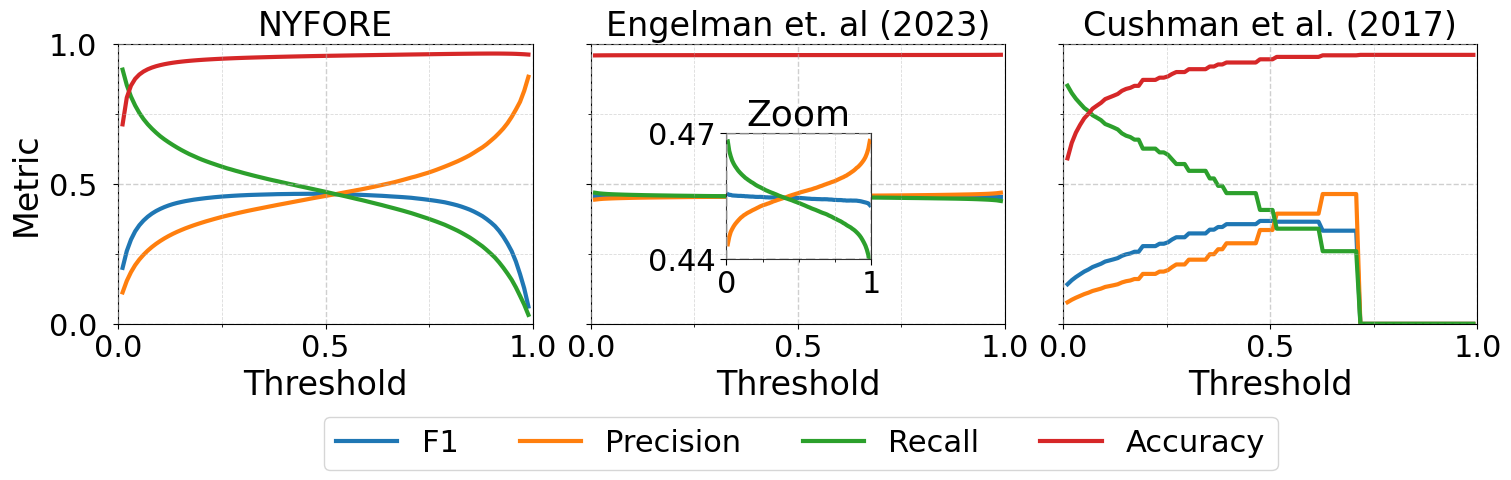

In [202]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---- Global style (publication) ----
plt.rcParams.update({
    "font.size": 26,
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "lines.linewidth": 3,
    "lines.markersize": 10,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, constrained_layout=True)

# ---- Choose zoom window for the middle panel ----
ZOOM_X = (0, 1)
ZOOM_Y = (0.44, 0.47)

for i, (ax, (k, d)) in enumerate(zip(axes, metrics_by_exp.items())):
    t = d["thresholds"]

    ax.plot(t, d["f1"], label="F1")
    ax.plot(t, d["precision"], label="Precision")
    ax.plot(t, d["recall"], label="Recall")
    ax.plot(t, d["accuracy"], label="Accuracy")

    ax.set_title(experiments[k]["name"])
    ax.set_xlabel("Threshold")
    ax.set_ylim(0, 1)
    ax.set_xlim(t.min(), t.max())

    # ---- ticks: major=0.5, minor=0.25 ----
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_minor_locator(MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.25))

    #ax.axvline(0.5, ls="--", lw=1, c="0.5", alpha=0.7)

    # ---- grid styling ----
    ax.set_axisbelow(False)
    ax.grid(True, which="major", linestyle="--", linewidth=1, alpha=0.6)
    ax.grid(True, which="minor", linestyle="--", linewidth=0.6, alpha=0.45)

    # ---- Middle panel: inset ----
    if i == 1:
        axins = inset_axes(
            ax,
            width="35%",
            height="45%",
            bbox_to_anchor=(0.327, 0.23, 1, 1),
            bbox_transform=ax.transAxes,
            loc="lower left",
            borderpad=0
        )

        axins.plot(t, d["f1"])
        axins.plot(t, d["precision"])
        axins.plot(t, d["recall"])
        axins.plot(t, d["accuracy"])

        axins.set_xlim(*ZOOM_X)
        axins.set_ylim(*ZOOM_Y)

        axins.set_xticks([0, 1])
        axins.set_yticks([0.44, 0.47])
        axins.xaxis.set_minor_locator(MultipleLocator(0.25))
        #axins.yaxis.set_minor_locator(MultipleLocator(0.01))

        axins.set_axisbelow(False)
        axins.grid(True, which="major", linestyle="--", linewidth=1.8, alpha=0.7)
        axins.grid(True, which="minor", linestyle="--", linewidth=0.6, alpha=0.45)

        axins.tick_params(labelsize=22, length=4, width=0.8)
        axins.set_xlabel("")
        axins.set_ylabel("")

        for spine in axins.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color("0.2")

        axins.set_title("Zoom", fontsize=26, pad=6)

axes[0].set_ylabel("Metric")
axes[0].tick_params(axis="y", pad=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.53, -0.2))
plt.savefig("ranking.pdf", bbox_inches="tight")

#plt.show()
